# Learning, warm-starting and going beyond QUBO with constraint-native QAOA

*Companion to `quantum_sensor_placement.ipynb`. That study found that, for budgeted maximum
coverage, the constraint-native XY-mixer QAOA (Dicke-state start) clearly outperforms penalty
QAOA, which at $p \le 3$ is almost a uniform sampler. This notebook takes the XY-mixer ansatz
as given and asks three follow-up questions.*

**Results in brief** (all from this notebook's single run; details and tests below).
- **E1 — quantum samples for a classical solver.** Taking the best of 10 XY-QAOA samples as the start of a
  short simulated-annealing run raises the probability of ending at the optimum over 10 random subsets by
  +0.049 ($n=12$, 18 wins / 0 losses), +0.086 ($n=14$, 11/0) and +0.031 on classically hard instances (9/2).
  Penalty-QAOA samples are no better than random. Greedy is better still on easy instances, where it is
  usually already optimal, but on the hard family the XY warm start beats greedy by +0.077.
- **E2 — learned parameters.** QAOA parameters concentrate strongly: one fixed parameter vector (the training
  median) gives $E[f/f^\star\mid$feasible$]$ = 0.780 on unseen $n=12$ instances and 0.787 at $n=14$, *above* full
  per-instance optimisation with 4 random restarts (0.772, 0.775). A graph neural network trained only on the
  QAOA energy adds a small, consistent gain without any optimisation (0.786 and 0.796; +0.006 and +0.008,
  Wilcoxon $p \approx 0.03$–$0.04$) and transfers to the larger, unseen size; after 30 COBYLA iterations the two are equal.
- **E3 — beyond QUBO.** Using the exact high-order coverage Hamiltonian instead of the quadratic proxy helps
  only where the proxy is wrong: on instances where the proxy's maximiser is not optimal, the probability of
  an optimal shot rises by +0.096 at $p=2$ (11/1, $p=0.007$); elsewhere gains are within noise. The exact
  cost layer needs about 1.7× (sparse) to 13–17× (dense) the two-qubit gates of the proxy after routing.
- **E4 — quantum samples as pretraining data.** An autoregressive network pretrained on 50 XY-QAOA shots
  starts with a higher probability of sampling an optimum than one pretrained on 50 random subsets (+0.049
  at $n=12$, 19/1) and keeps the lead in early classical fine-tuning; after 300 steps of variational
  annealing all variants converge to similar quality. Quantum samples give a head start, not an
  unreachable advantage, at this size.

| Part | Question |
|---|---|
| E1 | Do QAOA samples help a **classical** solver? Simulated annealing warm-started from QAOA samples vs random samples vs greedy, at a fixed short budget. |
| E2 | Can the circuit parameters be **learned** instead of optimised per instance? Parameter transfer (training-set median) vs a graph neural network trained directly on the QAOA energy, tested on unseen instances and on a larger $n$. |
| E3 | What does **leaving the QUBO** buy? The exact coverage objective (a high-order polynomial) as cost Hamiltonian vs the quadratic proxy: solution quality and gate cost. |
| E4 | Do QAOA samples help as **pretraining data for a classical generative solver** (an autoregressive network refined by variational annealing)? |

Conventions are those of the main notebook: exact simulation (no shot noise unless sampling is
part of the experiment), true coverage as the figure of merit, seeded randomness, 95% bootstrap
intervals over instances, paired Wilcoxon tests. Everything here is noiseless simulation at
$n \le 14$, where the problem is classically trivial; the questions are about mechanisms, not
advantage.

In [1]:
import os, json, time, itertools, platform, warnings
from importlib.metadata import version
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize
from scipy.stats import wilcoxon
import torch
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import PauliEvolutionGate, XXPlusYYGate
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeMarrakesh

warnings.filterwarnings('ignore', category=Warning, module='scipy.sparse')
torch.set_default_dtype(torch.float64)
plt.rcParams['figure.dpi'] = 110
SEED = 42
torch.manual_seed(SEED)
torch.set_num_threads(1)      # deterministic and fast for these tiny tensors
RESULTS_DIR = 'results_ext'
os.makedirs(RESULTS_DIR, exist_ok=True)
RUN_STARTED = time.time()
for pkg in ['qiskit', 'qiskit-ibm-runtime', 'numpy', 'scipy', 'torch']:
    print(f'{pkg:20s} {version(pkg)}')

qiskit               2.5.2
qiskit-ibm-runtime   0.50.0
numpy                2.5.3
scipy                1.18.1
torch                2.14.1


In [2]:
# =====================================================================================
# Helper library -- every function used in the notebook is defined here, once.
# (The previous version redefined helpers in several sections with different signatures;
#  that is gone: later sections only call what is defined in this cell.)
# =====================================================================================

# ---------------------------------------------------------------- instances & objective
def make_instance(n, seed, n_zones=25, box=10.0, radius=2.2):
    """Abstract instance: n stations and n_zones zones uniform in a box; station covers zone
    if their distance is <= radius. Returns the 0/1 coverage matrix (n x n_zones)."""
    rng = np.random.default_rng(seed)
    sx, sy = rng.uniform(0, box, n), rng.uniform(0, box, n)
    zx, zy = rng.uniform(0, box, n_zones), rng.uniform(0, box, n_zones)
    d = np.sqrt((sx[:, None] - zx[None, :]) ** 2 + (sy[:, None] - zy[None, :]) ** 2)
    return (d <= radius).astype(int)


def true_coverage(sel, cov):
    """The real objective: number of distinct zones covered by the selected stations."""
    sel = [int(i) for i in sel]
    if not sel:
        return 0
    return int((cov[sel].sum(axis=0) > 0).sum())


def bit_table(n):
    """bits[z, i] = value of qubit i in computational basis state z (Qiskit little-endian)."""
    z = np.arange(2 ** n)
    return ((z[:, None] >> np.arange(n)[None, :]) & 1).astype(np.int8)


def bits_to_sel(z, n):
    return [i for i in range(n) if (z >> i) & 1]


def true_coverage_all(cov):
    """True coverage of every one of the 2^n bitstrings (vectorised)."""
    B = bit_table(cov.shape[0]).astype(np.int32)
    return ((B @ cov) > 0).sum(axis=1)


def proxy_all(cov, lam):
    """QUBO proxy  sum_i c_i x_i - lam * sum_{i<j} o_ij x_i x_j  for every bitstring."""
    B = bit_table(cov.shape[0]).astype(float)
    c = cov.sum(axis=1).astype(float)
    O = (cov @ cov.T).astype(float)
    np.fill_diagonal(O, 0.0)
    return B @ c - lam * 0.5 * np.einsum('zi,ij,zj->z', B, O, B)


class Instance:
    """Precomputes everything that is evaluated exactly (n <= 14 -> at most 16384 states)."""

    def __init__(self, cov, k, lam=1.0, name=''):
        self.cov, self.k, self.lam, self.name = cov, k, lam, name
        self.n = cov.shape[0]
        self.w = bit_table(self.n).sum(axis=1)
        self.feas = self.w == k
        self.tc = true_coverage_all(cov)
        self.opt = int(self.tc[self.feas].max())
        self.proxy = proxy_all(cov, lam)
        self.c = cov.sum(axis=1)
        self.O = cov @ cov.T
        tc_f = self.tc[self.feas]
        self.random_mean_ratio = float(tc_f.mean() / self.opt)
        self.random_p_opt = float((tc_f == self.opt).mean())


# ---------------------------------------------------------------- classical baselines
def greedy_selection(cov, k):
    """Textbook greedy (1-1/e guarantee); ties broken by lowest index (deterministic)."""
    sel = []
    for _ in range(k):
        cand = [i for i in range(cov.shape[0]) if i not in sel]
        gains = [true_coverage(sel + [i], cov) for i in cand]
        sel.append(cand[int(np.argmax(gains))])
    return sel, true_coverage(sel, cov)


def lp_relaxation(cov, k):
    """LP relaxation of the exact max-coverage ILP (station AND zone variables)."""
    n, m = cov.shape
    c_lp = np.concatenate([np.zeros(n), -np.ones(m)])
    A_ub = np.zeros((m, n + m))
    for j in range(m):
        A_ub[j, :n] = -cov[:, j]
        A_ub[j, n + j] = 1
    A_eq = np.zeros((1, n + m))
    A_eq[0, :n] = 1
    res = linprog(c_lp, A_ub=A_ub, b_ub=np.zeros(m), A_eq=A_eq, b_eq=[k],
                  bounds=[(0, 1)] * (n + m), method='highs')
    return np.clip(res.x[:n], 0.0, 1.0), float(-res.fun)


def lp_topk(cov, k):
    """Deterministic rounding: keep the k largest LP values."""
    x, ub = lp_relaxation(cov, k)
    sel = [int(i) for i in np.argsort(-x, kind='stable')[:k]]
    return sel, true_coverage(sel, cov), x, ub


def lp_randomized_rounding(cov, k, n_trials=300, seed=0):
    """LP top-k plus randomized rounding with repair, best true coverage kept (heuristic;
    NOT the pipage rounding that carries the formal (1-1/e) guarantee)."""
    n = cov.shape[0]
    x, ub = lp_relaxation(cov, k)
    rng = np.random.default_rng(seed)
    best_sel, best_val, _, _ = lp_topk(cov, k)
    for _ in range(n_trials):
        probs = np.clip(x, 1e-6, 1 - 1e-6)
        s = [int(i) for i in np.where(rng.random(n) < probs)[0]]
        if len(s) > k:
            s = sorted(s, key=lambda i: -x[i])[:k]
        elif len(s) < k:
            rest = sorted((i for i in range(n) if i not in s), key=lambda i: -x[i])
            s += rest[:k - len(s)]
        v = true_coverage(s, cov)
        if v > best_val:
            best_sel, best_val = s, v
    return best_sel, best_val, ub


def qubo_proxy_objective(sel, c, O, lam):
    s = list(sel)
    return sum(c[i] for i in s) - lam * sum(O[s[a], s[b]] for a in range(len(s)) for b in range(a + 1, len(s)))


def simulated_annealing(cov, k, lam, n_iters=3000, n_restarts=3, seed=0):
    """Swap-move simulated annealing on the same QUBO proxy QAOA sees (always feasible)."""
    n = cov.shape[0]
    c, O = cov.sum(axis=1), cov @ cov.T
    rng = np.random.default_rng(seed)
    best_all, best_all_val = None, -np.inf
    for _ in range(n_restarts):
        cur = [int(i) for i in rng.choice(n, size=k, replace=False)]
        cur_val = qubo_proxy_objective(cur, c, O, lam)
        best, best_val, T = cur[:], cur_val, 2.0
        for _ in range(n_iters):
            out_pos = rng.integers(k)
            not_sel = [i for i in range(n) if i not in cur]
            cand = cur[:]
            cand[out_pos] = not_sel[rng.integers(len(not_sel))]
            cand_val = qubo_proxy_objective(cand, c, O, lam)
            if cand_val - cur_val > 0 or rng.random() < np.exp((cand_val - cur_val) / max(T, 1e-9)):
                cur, cur_val = cand, cand_val
                if cur_val > best_val:
                    best, best_val = cur[:], cur_val
            T *= 0.995
        if best_val > best_all_val:
            best_all, best_all_val = best, best_val
    return best_all, best_all_val


def proxy_argmax_ratio(inst):
    """True-coverage ratio of the proxy's best feasible bitstring (ties: worst case and mean)."""
    pf = inst.proxy[inst.feas]
    tc_f = inst.tc[inst.feas]
    arg = np.isclose(pf, pf.max())
    return float(tc_f[arg].min() / inst.opt), float(tc_f[arg].mean() / inst.opt)


# ---------------------------------------------------------------- operators / penalties
def fwht(a):
    """Fast Walsh-Hadamard transform (unnormalised)."""
    a = np.array(a, dtype=float)
    N, h = a.size, 1
    while h < N:
        a = a.reshape(-1, 2 * h)
        x, y = a[:, :h].copy(), a[:, h:].copy()
        a[:, :h], a[:, h:] = x + y, x - y
        a = a.reshape(N)
        h *= 2
    return a


def z_coeffs(diag):
    """Coefficients a_S of the Pauli-Z expansion diag = sum_S a_S prod_{i in S} Z_i.
    Index S is a bitmask; S = 0 is the identity (constant) term."""
    return fwht(diag) / diag.size


def pauli_one_norm(diag):
    """Total Pauli weight sum_{S != 0} |a_S| (identity excluded: it never affects gradients)."""
    a = z_coeffs(diag)
    return float(np.abs(a[1:]).sum())


def penalty_auto(inst):
    """qiskit-optimization's automatic penalty for an equality constraint: 1 + (sum of the
    absolute objective coefficients), an upper bound on the objective's range."""
    iu = np.triu_indices(inst.n, 1)
    return float(1 + inst.c.sum() + inst.lam * inst.O[iu].sum())


def penalty_tight(inst):
    """Smallest integer P with a proof that every minimiser of -proxy + P (sum x - k)^2 is
    feasible: removing a station from an over-full selection changes -proxy by at most c_i,
    adding one to an under-full selection by at most lam*sum_j o_ij - c_i, while the penalty
    changes by at least P. So P > max_i max(c_i, lam*sum_{j!=i} o_ij - c_i) suffices."""
    O = inst.O.astype(float).copy()
    np.fill_diagonal(O, 0)
    bound = np.maximum(inst.c, inst.lam * O.sum(axis=1) - inst.c).max()
    return float(np.floor(bound) + 1)


def cost_diag(inst, method):
    """Diagonal (over all 2^n basis states) of the cost Hamiltonian each method minimises.
    All entries are integers for lam = 1, so exp(-i gamma C) has period 2 pi in gamma."""
    if method == 'penalty_auto':
        return -inst.proxy + penalty_auto(inst) * (inst.w - inst.k) ** 2
    if method == 'penalty_tight':
        return -inst.proxy + penalty_tight(inst) * (inst.w - inst.k) ** 2
    if method in ('native', 'native_dicke'):
        return -inst.proxy.copy()           # no budget term: the mixer enforces it
    raise ValueError(method)


# ---------------------------------------------------------------- exact simulator
class Sim:
    """Exact statevector simulator for the ansatz families in this notebook.

    Parametrised gates are exp(-i * s * theta[idx] * G) with a known Hermitian generator G,
    which makes the adjoint (reverse-mode) gradient exact:
      ('diag', d, idx, s)     G = diag(d)                    cost layers
      ('rx', q, idx, s)       G = X_q / 2                    transverse mixer, s = 2 -> exp(-i beta X)
      ('ry', q, idx, s)       G = Y_q / 2                    hardware-efficient ansatz
      ('xy', (a, b), idx, s)  G = (X_a X_b + Y_a Y_b) / 2    one hop of the ring XY mixer
      ('cx', (c, t))          fixed CNOT
      ('par1', q, fn, idx)    single-qubit U = fn(theta[idx]) (forward only, no gradient)
    Validated against Qiskit's own circuits and gradients in Section 3.
    """

    def __init__(self, n):
        self.n, self.N = n, 2 ** n
        z = np.arange(self.N)
        self._z = z
        self._masks = {}

    def _apply1(self, psi, q, U):
        t = psi.reshape([2] * self.n)
        ax = self.n - 1 - q
        t = np.moveaxis(np.tensordot(U, t, axes=([1], [ax])), 0, ax)
        return t.reshape(self.N)

    def _xy(self, a, b):
        if (a, b) not in self._masks:
            z = self._z
            i01 = z[(((z >> a) & 1) == 1) & (((z >> b) & 1) == 0)]
            self._masks[(a, b)] = (i01, i01 - (1 << a) + (1 << b))
        return self._masks[(a, b)]

    def apply(self, psi, g, theta, inverse=False):
        sg = -1.0 if inverse else 1.0
        kind = g[0]
        if kind == 'diag':
            return psi * np.exp(-1j * sg * g[3] * theta[g[2]] * g[1])
        if kind in ('rx', 'ry'):
            a = sg * g[3] * theta[g[2]] / 2
            c, s = np.cos(a), np.sin(a)
            U = np.array([[c, -1j * s], [-1j * s, c]]) if kind == 'rx' else np.array([[c, -s], [s, c]])
            return self._apply1(psi, g[1], U)
        if kind == 'xy':
            i01, i10 = self._xy(*g[1])
            a = sg * g[3] * theta[g[2]]
            out = psi.copy()
            out[i01] = np.cos(a) * psi[i01] - 1j * np.sin(a) * psi[i10]
            out[i10] = np.cos(a) * psi[i10] - 1j * np.sin(a) * psi[i01]
            return out
        if kind == 'cx':
            c_, t_ = g[1]
            z = self._z
            return psi[np.where(((z >> c_) & 1) == 1, z ^ (1 << t_), z)]
        if kind == 'par1':
            U = g[2](theta[g[3]])
            return self._apply1(psi, g[1], U.conj().T if inverse else U)
        raise ValueError(kind)

    def generator(self, psi, g):
        kind = g[0]
        if kind == 'diag':
            return g[1] * psi
        if kind == 'rx':
            return self._apply1(psi, g[1], np.array([[0, 0.5], [0.5, 0]], dtype=complex))
        if kind == 'ry':
            return self._apply1(psi, g[1], np.array([[0, -0.5j], [0.5j, 0]]))
        if kind == 'xy':
            i01, i10 = self._xy(*g[1])
            out = np.zeros_like(psi)
            out[i01], out[i10] = psi[i10], psi[i01]
            return out
        raise ValueError(kind)

    def state(self, psi0, gates, theta):
        psi = np.array(psi0, dtype=complex)
        for g in gates:
            psi = self.apply(psi, g, theta)
        return psi

    def energy(self, psi0, gates, theta, obs):
        psi = self.state(psi0, gates, theta)
        return float(np.real(np.vdot(psi, obs * psi)))

    def energy_and_grad(self, psi0, gates, theta, obs, n_params):
        """Adjoint differentiation. For U = exp(-i s theta G) applied at some point,
        dE/dtheta = 2 s Im <lambda|G|phi>, phi = state right after U, lambda = (rest)^dag O psi.
        Contributions of all gates sharing a parameter are summed."""
        psi = self.state(psi0, gates, theta)
        E = float(np.real(np.vdot(psi, obs * psi)))
        lam, phi = obs * psi, psi
        grad = np.zeros(n_params)
        for g in reversed(gates):
            if g[0] in ('diag', 'rx', 'ry', 'xy'):
                grad[g[2]] += 2 * g[3] * np.imag(np.vdot(lam, self.generator(phi, g)))
            phi = self.apply(phi, g, theta, inverse=True)
            lam = self.apply(lam, g, theta, inverse=True)
        return E, grad


def plus_state(n):
    return np.full(2 ** n, 2 ** (-n / 2), dtype=complex)


def first_k_state(n, k):
    """|1...1 0...0>: qubits 0..k-1 set (the feasible basis state used by Hadfield et al.)."""
    psi = np.zeros(2 ** n, dtype=complex)
    psi[(1 << k) - 1] = 1.0
    return psi


def dicke_state(n, k):
    """Uniform superposition over all weight-k bitstrings (the feasible analogue of |+>^n)."""
    w = bit_table(n).sum(axis=1)
    psi = (w == k).astype(complex)
    return psi / np.linalg.norm(psi)


def ring_pairs(n):
    return [(i, (i + 1) % n) for i in range(n)]


def gates_transverse(n, d, p):
    """Standard QAOA. theta = [gamma_0..gamma_{p-1}, beta_0..beta_{p-1}];
    layer = exp(-i gamma C) then exp(-i beta sum_i X_i)."""
    gates = []
    for l in range(p):
        gates.append(('diag', d, l, 1.0))
        gates += [('rx', q, p + l, 2.0) for q in range(n)]
    return gates


def gates_ring_xy(n, d, p):
    """Constraint-native QAOA: exp(-i gamma C), then the ring XY mixer as one Trotter step,
    hops (0,1),(1,2),...,(n-1,0), each exp(-i beta (XX+YY)/2). Every hop conserves Hamming
    weight exactly, so the product does too, regardless of Trotter error."""
    gates = []
    for l in range(p):
        gates.append(('diag', d, l, 1.0))
        gates += [('xy', pr, p + l, 1.0) for pr in ring_pairs(n)]
    return gates


def gates_real_amplitudes(n, reps):
    """Same structure as qiskit's real_amplitudes(n, reps, entanglement='linear')."""
    gates, idx = [], 0
    for q in range(n):
        gates.append(('ry', q, idx, 1.0)); idx += 1
    for _ in range(reps):
        gates += [('cx', (q, q + 1)) for q in range(n - 1)]
        for q in range(n):
            gates.append(('ry', q, idx, 1.0)); idx += 1
    return gates, idx


METHODS = ['penalty_auto', 'penalty_tight', 'native', 'native_dicke']
METHOD_LABELS = {'penalty_auto': 'Penalty QAOA, P auto (qiskit default)',
                 'penalty_tight': 'Penalty QAOA, P tight',
                 'native': 'XY-mixer QAOA, basis-state start',
                 'native_dicke': 'XY-mixer QAOA, Dicke-state start'}
METHOD_COLORS = {'penalty_auto': '#d62728', 'penalty_tight': '#ff9896',
                 'native': '#2ca02c', 'native_dicke': '#1f77b4'}


def ansatz_for(inst, method, p):
    """(sim, gates, psi0, cost diagonal) for one method on one instance."""
    n, k = inst.n, inst.k
    d = cost_diag(inst, method)
    if method.startswith('penalty'):
        return Sim(n), gates_transverse(n, d, p), plus_state(n), d
    psi0 = first_k_state(n, k) if method == 'native' else dicke_state(n, k)
    return Sim(n), gates_ring_xy(n, d, p), psi0, d


# ---------------------------------------------------------------- optimisation & metrics
def optimise_qaoa(inst, method, p, n_restarts, seed, gamma_scale, maxiter, built=None, x0_fixed=None):
    """COBYLA on the exact energy. gamma = gamma_scale * u / max|Pauli coeff of C|; u_0 ~ U[0,1],
    beta_0 ~ U[0, pi/2] (from no mixing to a full flip/swap for both mixers).
    The restart with the LOWEST ENERGY is kept -- never selected using the true coverage,
    which a real user would not know. Returns the best parameters and exact probabilities.
    `built` = (sim, gates, psi0, d) overrides the ansatz (appendices); `x0_fixed` = one given
    starting point in the same (u, beta) units instead of random restarts."""
    sim, gates, psi0, d = ansatz_for(inst, method, p) if built is None else built
    a = z_coeffs(d)
    scale = gamma_scale / np.abs(a[1:]).max()
    S = np.concatenate([np.full(p, scale), np.ones(p)])
    f = lambda u: sim.energy(psi0, gates, S * u, d)
    rng = np.random.default_rng(seed)
    best, nfev = None, 0
    starts = [np.asarray(x0_fixed, float)] if x0_fixed is not None else \
        [np.concatenate([rng.uniform(0, 1, p), rng.uniform(0, np.pi / 2, p)]) for _ in range(n_restarts)]
    for x0 in starts:
        res = minimize(f, x0, method='COBYLA', options={'maxiter': maxiter, 'rhobeg': 0.2})
        nfev += res.nfev
        if best is None or res.fun < best.fun:
            best = res
    theta = S * best.x
    probs = np.abs(sim.state(psi0, gates, theta)) ** 2
    return theta, probs, best.fun, nfev, best.x


def expected_best_of(values, probs, shots):
    """E[max of `shots` iid draws] for a discrete distribution (exact, no sampling)."""
    order = np.argsort(values)
    v, pr = np.asarray(values, float)[order], np.asarray(probs, float)[order]
    uv, inv = np.unique(v, return_inverse=True)
    pm = np.bincount(inv, weights=pr, minlength=uv.size)
    F = np.clip(np.cumsum(pm), 0, 1)
    F_prev = np.concatenate([[0.0], F[:-1]])
    return float(np.sum(uv * (F ** shots - F_prev ** shots)))


def output_metrics(inst, probs, shots_list=(1, 10, 100)):
    """Exact output statistics of a state with basis-state probabilities `probs`.
    Infeasible outcomes score 0 (in practice they are discarded; they still cost shots)."""
    probs = probs / probs.sum()
    feas, tc, opt = inst.feas, inst.tc, inst.opt
    p_feas = float(probs[feas].sum())
    ratio = np.where(feas, tc / opt, 0.0)
    zf = np.where(feas)[0]
    top = zf[np.argsort(-probs[zf], kind='stable')]
    m = {
        'p_feasible': p_feas,
        'ratio_cond': float((probs[feas] * ratio[feas]).sum() / p_feas) if p_feas > 0 else np.nan,
        'p_opt': float(probs[feas & (tc == opt)].sum()),
        'ratio_top1': float(tc[top[0]] / opt),
    }
    for s in shots_list:
        m[f'best_of_{s}'] = expected_best_of(ratio, probs, s)
    return m


def random_metrics(inst, shots_list=(1, 10, 100)):
    """Same metrics for the classical null: uniformly random feasible k-subsets."""
    r = inst.tc[inst.feas] / inst.opt
    pr = np.full(r.size, 1.0 / r.size)
    m = {'p_feasible': 1.0, 'ratio_cond': float(r.mean()), 'p_opt': float((r == 1).mean()), 'ratio_top1': np.nan}
    for s in shots_list:
        m[f'best_of_{s}'] = expected_best_of(r, pr, s)
    return m


# ---------------------------------------------------------------- statistics
def boot_ci(x, n_boot=2000, seed=0, stat=np.mean, alpha=0.05):
    """Percentile bootstrap CI over independent units (instances)."""
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    if x.size == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    bs = np.array([stat(x[rng.integers(0, x.size, x.size)]) for _ in range(n_boot)])
    return float(stat(x)), float(np.quantile(bs, alpha / 2)), float(np.quantile(bs, 1 - alpha / 2))


def fmt_ci(t, digits=3):
    m, lo, hi = t
    return f'{m:.{digits}f} [{lo:.{digits}f}, {hi:.{digits}f}]'

In [3]:
# Settings shared by all three experiments (identical to the main study's XY-mixer runs)
GAMMA_SCALE_XY = 0.3        # calibrated value for the Dicke-start XY mixer in the main notebook
MAXITER, N_RESTARTS = 250, 4
COLORS = {'xy': '#2a78d6', 'penalty': '#eb6834', 'random': '#8a8a8a', 'greedy': '#1baf7a',
          'median': '#eda100', 'gnn': '#e87ba4', 'exact': '#2a78d6', 'proxy': '#eb6834'}


def xy_built(inst, p, cost='proxy'):
    """(sim, gates, psi0, diag) for the Dicke-start XY mixer with the proxy or the exact cost."""
    d = -inst.proxy if cost == 'proxy' else -inst.tc.astype(float)
    return Sim(inst.n), gates_ring_xy(inst.n, d, p), dicke_state(inst.n, inst.k), d


def diag_to_sparse_pauli(diag):
    """SparsePauliOp (Z terms only) equal to diag minus its constant term."""
    n = int(np.log2(diag.size))
    a = z_coeffs(diag)
    terms = [(''.join('Z' if (S >> (n - 1 - j)) & 1 else 'I' for j in range(n)), a[S]) for S in range(1, diag.size) if abs(a[S]) > 1e-12]
    return SparsePauliOp.from_list(terms), a[0]


def qiskit_native_circuit(inst, p, H_C):
    """XY-mixer QAOA with basis start as a Qiskit circuit (same hop order as gates_ring_xy)."""
    g, b = ParameterVector('g', p), ParameterVector('b', p)
    qc = QuantumCircuit(inst.n)
    for i in range(inst.k):
        qc.x(i)
    for l in range(p):
        qc.append(PauliEvolutionGate(H_C, time=g[l]), range(inst.n))
        for a_, b_ in ring_pairs(inst.n):
            qc.append(XXPlusYYGate(2 * b[l]), [a_, b_])
    return qc


def paired_test(a, b):
    diff = np.asarray(a) - np.asarray(b)
    return diff, (wilcoxon(diff).pvalue if np.any(diff != 0) else 1.0)

## E1. Quantum samples as warm starts for a classical solver

**Question.** If a QAOA circuit is run for a handful of shots and the best sample is handed to a
classical local search, does the search reach the optimum faster than from equally many random
samples, or from greedy?

**Protocol.** For each instance, the XY-mixer QAOA ($p=3$, Dicke start) and, for comparison,
penalty QAOA ($P_\text{tight}$, $p=3$) are optimised as in the main study. Then, in each of
`N_SA_RUNS` seeded trials: draw $S$ = `S_SHOTS` samples from the source (QAOA output
distribution, or uniform random $k$-subsets); keep the best feasible one (if a penalty batch has
no feasible sample, a random subset is used instead); run swap-move simulated annealing on the
**true** coverage for a fixed budget of `SA_BUDGET` moves. A greedy start (deterministic) is
also run with the same SA. Reported: probability of ending at the optimum, and mean number of
moves to first reach it (censored at the budget). The $S$ evaluations of the starting samples
are the same for all sources, so budgets are matched.

In [4]:
S_SHOTS, SA_BUDGET, N_SA_RUNS, SA_T0 = 10, 60, 300, 1.0


def sa_from(inst, z0, rng, budget=SA_BUDGET, T0=SA_T0):
    """Swap-move simulated annealing on the true coverage, state = bitmask. Returns (final ratio, moves to optimum or None)."""
    n, tc, opt = inst.n, inst.tc, inst.opt
    z, val = int(z0), int(tc[z0])
    if val == opt:
        return 1.0, 0
    T = T0
    for t in range(1, budget + 1):
        ones = [i for i in range(n) if (z >> i) & 1]
        zeros = [i for i in range(n) if not (z >> i) & 1]
        z2 = z ^ (1 << ones[rng.integers(len(ones))]) ^ (1 << zeros[rng.integers(len(zeros))])
        v2 = int(tc[z2])
        if v2 >= val or rng.random() < np.exp((v2 - val) / max(T, 1e-9)):
            z, val = z2, v2
            if val == opt:
                return 1.0, t
        T *= 0.97
    return val / opt, None


def best_start(inst, probs, rng):
    zs = rng.choice(probs.size, size=S_SHOTS, p=probs / probs.sum())
    zf = [z for z in zs if inst.feas[z]]
    if not zf:
        return None
    return max(zf, key=lambda z: inst.tc[z])


E1_SETS = {'R, n=12': ('R', 12, 2.2, 20), 'R, n=14': ('R', 14, 2.2, 12), 'H, n=12': ('H', 12, 3.0, 12)}


def make_set(fam, n, radius, count, seed0):
    out, s = [], 0
    while len(out) < count:
        cov_ = make_instance(n, seed=seed0 + s, radius=radius)
        inst_ = Instance(cov_, round(n / 3))
        if fam == 'R' or (greedy_selection(cov_, inst_.k)[1] < inst_.opt and lp_topk(cov_, inst_.k)[1] < inst_.opt):
            out.append(inst_)
        s += 1
    return out


SOURCES_IDX = {'xy': 1, 'penalty': 2, 'random': 3, 'greedy': 4}
e1_rows, e1_inst, e1_probs = [], {}, {}
t0 = time.time()
for set_name, (fam, n_, radius, count) in E1_SETS.items():
    insts = make_set(fam, n_, radius, count, seed0=1_100_000 + 1000 * n_ + (500 if fam == 'H' else 0))
    e1_inst[set_name] = insts
    for j, inst in enumerate(insts):
        _, pr_xy, *_ = optimise_qaoa(inst, 'native_dicke', 3, N_RESTARTS, SEED + j, GAMMA_SCALE_XY, MAXITER, built=xy_built(inst, 3))
        e1_probs[(set_name, j)] = pr_xy
        _, pr_pen, *_ = optimise_qaoa(inst, 'penalty_tight', 3, N_RESTARTS, SEED + j, 0.3, MAXITER)
        uniform = np.where(inst.feas, 1.0, 0.0)
        z_greedy = sum(1 << i for i in greedy_selection(inst.cov, inst.k)[0])
        for source, probs in [('xy', pr_xy), ('penalty', pr_pen), ('random', uniform), ('greedy', None)]:
            rng = np.random.default_rng(SEED * 1000 + 17 * j + SOURCES_IDX[source])
            succ, hit = [], []
            for _ in range(N_SA_RUNS):
                if source == 'greedy':
                    z0 = z_greedy
                else:
                    z0 = best_start(inst, probs, rng)
                    if z0 is None:
                        z0 = best_start(inst, uniform, rng)
                r, t_hit = sa_from(inst, z0, rng)
                succ.append(r == 1.0)
                hit.append(SA_BUDGET + 1 if t_hit is None else t_hit)
            e1_rows.append({'set': set_name, 'instance': j, 'source': source, 'p_success': np.mean(succ),
                            'mean_moves_to_opt': np.mean(hit), 'start_is_opt': np.mean(np.array(hit) == 0)})
    print(f'{set_name}: done [{time.time() - t0:.0f}s]')
e1_df = pd.DataFrame(e1_rows)
e1_df.to_csv(f'{RESULTS_DIR}/e1_sa_warmstart.csv', index=False)

R, n=12: done [103s]


R, n=14: done [240s]


H, n=12: done [311s]


P(start already optimal)   P(optimal after SA)  \
set     start                                                                 
R, n=12 XY-QAOA samples          0.384 [0.279, 0.491]  0.907 [0.875, 0.940]   
        penalty-QAOA samples     0.053 [0.031, 0.083]  0.847 [0.789, 0.897]   
        random subsets           0.087 [0.052, 0.131]  0.859 [0.811, 0.905]   
        greedy                   1.000 [1.000, 1.000]  1.000 [1.000, 1.000]   
R, n=14 XY-QAOA samples          0.244 [0.119, 0.406]  0.743 [0.632, 0.853]   
        penalty-QAOA samples     0.052 [0.011, 0.126]  0.680 [0.552, 0.809]   
        random subsets           0.075 [0.015, 0.179]  0.656 [0.522, 0.794]   
        greedy                   0.750 [0.500, 1.000]  0.864 [0.705, 1.000]   
H, n=12 XY-QAOA samples          0.234 [0.115, 0.372]  0.736 [0.638, 0.829]   
        penalty-QAOA samples     0.052 [0.029, 0.087]  0.698 [0.605, 0.792]   
        random subsets           0.086 [0.047, 0.146]  0.705 [0.615, 0.798]   
        greedy                   0.000 [0.000, 0.000]  0.659 [0.554, 0.763]   

                             mean moves to optimum (censored)  
set     start                                                  
R, n=12 XY-QAOA samples                     16.7 [12.8, 20.5]  
        penalty-QAOA samples                28.1 [24.0, 32.0]  
        random subsets                      26.4 [22.1, 30.5]  
        greedy                                 0.0 [0.0, 0.0]  
R, n=14 XY-QAOA samples                     28.5 [19.9, 35.7]  
        penalty-QAOA samples                36.5 [28.3, 43.3]  
        random subsets                      36.2 [27.2, 43.7]  
        greedy                               11.5 [0.0, 23.4]  
H, n=12 XY-QAOA samples                     28.4 [20.8, 35.7]  
        penalty-QAOA samples                34.3 [28.7, 39.4]  
        random subsets                      33.0 [27.2, 38.2]  
        greedy                              37.5 [30.7, 43.6]

,set,comparison,mean diff P(optimal),wins,losses,wilcoxon_p
0,"R, n=12",xy - random,"0.049 [0.027, 0.074]",18,0,0.0002
1,"R, n=12",xy - penalty,"0.061 [0.035, 0.091]",20,0,0.0001
2,"R, n=12",xy - greedy,"-0.093 [-0.126, -0.061]",0,17,0.0003
3,"R, n=14",xy - random,"0.086 [0.047, 0.125]",11,0,0.0010
4,"R, n=14",xy - penalty,"0.063 [0.032, 0.095]",11,1,0.0024
5,"R, n=14",xy - greedy,"-0.121 [-0.226, -0.019]",3,8,0.0508
6,"H, n=12",xy - random,"0.031 [0.014, 0.049]",9,2,0.0068
7,"H, n=12",xy - penalty,"0.038 [0.014, 0.063]",10,2,0.0107
8,"H, n=12",xy - greedy,"0.077 [0.021, 0.131]",10,2,0.0210


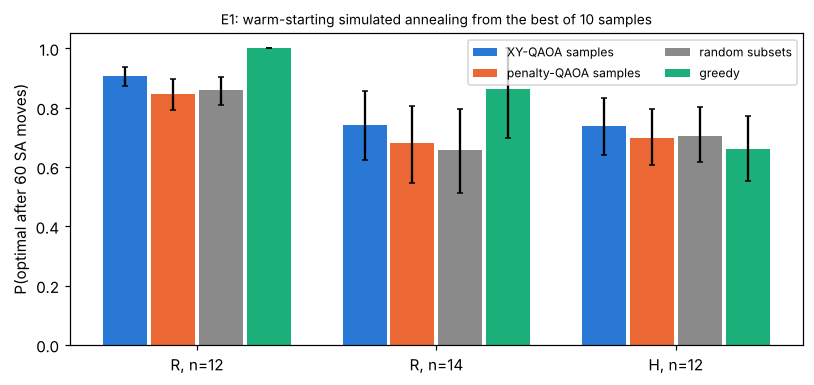

In [5]:
SOURCES = ['xy', 'penalty', 'random', 'greedy']
SRC_LABEL = {'xy': 'XY-QAOA samples', 'penalty': 'penalty-QAOA samples', 'random': 'random subsets', 'greedy': 'greedy'}
tab = []
for set_name in E1_SETS:
    for src in SOURCES:
        s_ = e1_df[(e1_df.set == set_name) & (e1_df.source == src)]
        tab.append({'set': set_name, 'start': SRC_LABEL[src], 'P(start already optimal)': fmt_ci(boot_ci(s_.start_is_opt, seed=1)),
                    'P(optimal after SA)': fmt_ci(boot_ci(s_.p_success, seed=1)),
                    'mean moves to optimum (censored)': fmt_ci(boot_ci(s_.mean_moves_to_opt, seed=1), 1)})
e1_tab = pd.DataFrame(tab).set_index(['set', 'start'])
display(e1_tab)
e1_tests = []
for set_name in E1_SETS:
    a = e1_df[(e1_df.set == set_name) & (e1_df.source == 'xy')].sort_values('instance')
    for other in ['random', 'penalty', 'greedy']:
        b = e1_df[(e1_df.set == set_name) & (e1_df.source == other)].sort_values('instance')
        diff, pv = paired_test(a.p_success.values, b.p_success.values)
        e1_tests.append({'set': set_name, 'comparison': f'xy - {other}', 'mean diff P(optimal)': fmt_ci(boot_ci(diff, seed=2)),
                         'wins': int((diff > 0).sum()), 'losses': int((diff < 0).sum()), 'wilcoxon_p': pv})
e1_tests = pd.DataFrame(e1_tests)
display(e1_tests.round(4))

fig, ax = plt.subplots(figsize=(7.5, 3.6))
w = 0.2
for k_, src in enumerate(SOURCES):
    vals = [boot_ci(e1_df[(e1_df.set == s) & (e1_df.source == src)].p_success, seed=3) for s in E1_SETS]
    m, lo, hi = np.array(vals).T
    ax.bar(np.arange(3) + (k_ - 1.5) * w, m, w * 0.92, yerr=[m - lo, hi - m], capsize=2, color=COLORS[src], label=SRC_LABEL[src])
ax.set_xticks(range(3)); ax.set_xticklabels(list(E1_SETS)); ax.set_ylim(0, 1.05)
ax.set_ylabel(f'P(optimal after {SA_BUDGET} SA moves)'); ax.legend(fontsize=8, ncol=2)
ax.set_title(f'E1: warm-starting simulated annealing from the best of {S_SHOTS} samples', fontsize=9)
plt.tight_layout(); plt.show()

**Reading.** XY-QAOA samples make simulated annealing reach the optimum more often than
equally many random samples on every set (paired tests above), and penalty-QAOA samples do not. Most of the gain
comes from the starting point already being optimal more often (0.38 vs 0.09 at $n=12$); the rest
from starting closer to it (16.7 vs 26.4 moves on average). Greedy is a much stronger start on family R,
where it is usually exact; on family H, where greedy is wrong by construction, the XY warm start is
the best of the four. Not counted here: the cost of optimising the circuit (handled by E2, which
removes most of it). This is a small-$n$, noiseless effect on a problem that annealing solves anyway with a
longer budget; the budget (`SA_BUDGET` moves) was fixed in advance to make the comparison discriminating.

## E2. Learning the circuit parameters

**Question.** Per-instance optimisation of QAOA parameters is the expensive part of the
algorithm. Can a model predict good parameters for an unseen instance — including one larger
than any in training — so that little or no optimisation is needed?

**Ansatz and parameter units.** XY mixer, Dicke start, $p = 2$ (four parameters). Angles are
expressed as $\tilde\gamma_l = \gamma_l \max_S|a_S|$ (the cost scaled to unit largest Pauli coefficient) and
$\beta_l$; these units transfer across instances whose costs have different magnitudes.

**Methods compared on held-out instances.**
- *random*: parameters drawn from the initialisation distribution of the main study (average over 20 draws);
- *median transfer*: the coordinate-wise median of per-instance optimal parameters over the training set
  (one fixed parameter vector for every instance; exploits parameter concentration);
- *GNN*: a message-passing network on the overlap graph (stations = nodes, $o_{ij}$ = edge weights),
  permutation-invariant by construction, trained **without labels** by minimising the QAOA energy of its
  predicted parameters over the training instances (a differentiable simulator restricted to the
  $\binom{n}{k}$-dimensional feasible subspace);
- each of the above followed by a short COBYLA refinement (`REFINE_ITERS` iterations);
- *per-instance optimum*: the full optimisation of the main study (4 restarts × 250 iterations), as a ceiling.

**Data.** Training: family R, $n \in \{8, 10, 12\}$, `N_TRAIN_PER_N` instances each. Test: 30 new instances
at $n = 12$ (in distribution) and 12 at $n = 14$ (larger than any training instance).

In [6]:
class SubspaceXY:
    """Exact XY-mixer QAOA restricted to the weight-k subspace (dimension C(n,k)), differentiable in torch.
    Validated against the full-space numpy simulator below."""

    def __init__(self, inst, cost_diag):
        n, k = inst.n, inst.k
        self.basis = np.where(inst.feas)[0]
        pos = {int(b): i for i, b in enumerate(self.basis)}
        self.cost = torch.tensor(np.asarray(cost_diag, float)[self.basis])
        self.dim = len(self.basis)
        self.hops = []
        for a, b in ring_pairs(n):
            src = [int(x) for x in self.basis if (x >> a) & 1 and not (x >> b) & 1]
            self.hops.append((torch.tensor([pos[x] for x in src]), torch.tensor([pos[x - (1 << a) + (1 << b)] for x in src])))

    def state(self, gam, bet):
        psi = torch.full((self.dim,), 1 / np.sqrt(self.dim), dtype=torch.complex128)
        for g, b in zip(gam, bet):
            psi = psi * torch.exp(-1j * g * self.cost)
            c, s = torch.cos(b), torch.sin(b)
            for i01, i10 in self.hops:
                a0, a1 = psi[i01], psi[i10]
                psi = psi.index_put((i01,), c * a0 - 1j * s * a1).index_put((i10,), c * a1 - 1j * s * a0)
        return psi

    def energy(self, gam, bet):
        return ((self.state(gam, bet).abs() ** 2) * self.cost).sum()


def cost_scale(inst):
    a = z_coeffs(-inst.proxy); return float(np.abs(a[1:]).max())


# validation against the numpy simulator (state and gradient)
inst_v = Instance(make_instance(10, seed=3), 3)
th_v = np.array([0.3, 0.7, 0.4, 1.1])
sim_v, g_v, psi0_v, d_v = xy_built(inst_v, 2)
T_v = SubspaceXY(inst_v, d_v)
gt, bt = torch.tensor(th_v[:2], requires_grad=True), torch.tensor(th_v[2:], requires_grad=True)
fid = abs(np.vdot(sim_v.state(psi0_v, g_v, th_v)[T_v.basis], T_v.state(gt, bt).detach().numpy())) ** 2
T_v.energy(gt, bt).backward()
_, g_np = sim_v.energy_and_grad(psi0_v, g_v, th_v, d_v, 4)
print(f'subspace simulator: 1 - fidelity = {1 - fid:.1e}, max |grad diff| = {np.abs(np.r_[gt.grad.numpy(), bt.grad.numpy()] - g_np).max():.1e}')
assert 1 - fid < 1e-10 and np.allclose(np.r_[gt.grad.numpy(), bt.grad.numpy()], g_np, atol=1e-9)

subspace simulator: 1 - fidelity = -8.9e-16, max |grad diff| = 8.4e-15


In [7]:
P_E2, N_TRAIN_PER_N, REFINE_ITERS = 2, 60, 30
TRAIN_N, TEST_SETS = [8, 10, 12], {'n=12 (in distribution)': (12, 30), 'n=14 (larger than training)': (14, 12)}

train = [Instance(make_instance(n_, seed=1_200_000 + 1000 * n_ + s), round(n_ / 3)) for n_ in TRAIN_N for s in range(N_TRAIN_PER_N)]
tests = {name: [Instance(make_instance(n_, seed=1_300_000 + 1000 * n_ + s), round(n_ / 3)) for s in range(cnt)]
         for name, (n_, cnt) in TEST_SETS.items()}

# per-instance optimisation of the training set (labels used only by the median baseline)
t0 = time.time()
train_theta = []
for j, inst in enumerate(train):
    th, *_ = optimise_qaoa(inst, 'native_dicke', P_E2, N_RESTARTS, SEED + j, GAMMA_SCALE_XY, MAXITER, built=xy_built(inst, P_E2))
    train_theta.append(np.r_[th[:P_E2] * cost_scale(inst), th[P_E2:]])
train_theta = np.array(train_theta)
THETA_MEDIAN = np.median(train_theta, axis=0)
print(f'training labels: {len(train)} instances [{time.time() - t0:.0f}s]')
print('median parameters (gamma~_1, gamma~_2, beta_1, beta_2):', THETA_MEDIAN.round(3))
print('inter-quartile range per parameter:', (np.quantile(train_theta, .75, axis=0) - np.quantile(train_theta, .25, axis=0)).round(3))

training labels: 180 instances [258s]
median parameters (gamma~_1, gamma~_2, beta_1, beta_2): [-0.364 -0.833  0.599  0.35 ]
inter-quartile range per parameter: [0.463 0.53  0.894 0.17 ]


In [8]:
def graph_features(inst):
    O = inst.O.astype(float).copy(); np.fill_diagonal(O, 0.0)
    x = np.stack([inst.c / 25, O.sum(1) / 25, (O > 0).sum(1) / inst.n,
                  np.full(inst.n, inst.k / inst.n), np.full(inst.n, inst.n / 14)], axis=1)
    A = O / max(O.max(), 1.0)
    return torch.tensor(x), torch.tensor(A)


class CoverageGNN(torch.nn.Module):
    """3 rounds of weighted message passing on the overlap graph, mean+max pooling, MLP -> 2p angles
    (gamma~_1..p, beta_1..p). No labels and no median are used: the angles are learned from scratch
    by minimising the energy."""

    def __init__(self, p, d_in=5, h=32):
        super().__init__()
        self.p = p
        self.inp = torch.nn.Linear(d_in, h)
        self.self_w = torch.nn.ModuleList([torch.nn.Linear(h, h) for _ in range(3)])
        self.nb_w = torch.nn.ModuleList([torch.nn.Linear(h, h, bias=False) for _ in range(3)])
        self.head = torch.nn.Sequential(torch.nn.Linear(2 * h, h), torch.nn.Tanh(), torch.nn.Linear(h, 2 * p))

    def forward(self, x, A):
        hdn = torch.tanh(self.inp(x))
        deg = A.sum(1, keepdim=True).clamp(min=1e-9)
        for ws, wn in zip(self.self_w, self.nb_w):
            hdn = torch.tanh(ws(hdn) + wn(A @ hdn / deg))
        out = self.head(torch.cat([hdn.mean(0), hdn.max(0).values]))
        return out[:self.p], out[self.p:]        # unconstrained: optimal scaled gammas are negative here


train_data = []
for inst in train:
    d = -inst.proxy
    T = SubspaceXY(inst, d)
    e_f = d[inst.feas]
    train_data.append((graph_features(inst), T, cost_scale(inst), float(e_f.min()), float(e_f.max())))


def normalised_energy(model, data):
    (x, A), T, sc, emin, emax = data
    gam, bet = model(x, A)
    return (T.energy(gam / sc, bet) - emin) / (emax - emin)


N_EPOCHS, N_MODEL_SEEDS = 150, 3
best_model, best_loss, t0 = None, np.inf, time.time()
for ms in range(N_MODEL_SEEDS):
    torch.manual_seed(SEED + ms)
    model = CoverageGNN(P_E2)
    opt = torch.optim.Adam(model.parameters(), lr=3e-3)
    order_rng = np.random.default_rng(SEED + ms)
    for epoch in range(N_EPOCHS):
        for batch in np.array_split(order_rng.permutation(len(train_data)), 12):
            if len(batch) == 0:
                continue
            opt.zero_grad()
            loss = torch.stack([normalised_energy(model, train_data[i]) for i in batch]).mean()
            loss.backward(); opt.step()
    with torch.no_grad():
        full = float(torch.stack([normalised_energy(model, dd) for dd in train_data]).mean())
    print(f'model seed {ms}: final training loss (normalised energy) {full:.4f} [{time.time() - t0:.0f}s]')
    if full < best_loss:
        best_model, best_loss = model, full
with torch.no_grad():
    med_train = float(np.mean([((dd[1].energy(torch.tensor(THETA_MEDIAN[:P_E2]) / dd[2], torch.tensor(THETA_MEDIAN[P_E2:])) - dd[3]) / (dd[4] - dd[3])).item()
                               for dd in train_data]))
print(f'for reference, the median parameters give a training loss of {med_train:.4f}')

model seed 0: final training loss (normalised energy) 0.2397 [138s]


model seed 1: final training loss (normalised energy) 0.2246 [275s]


model seed 2: final training loss (normalised energy) 0.2393 [409s]
for reference, the median parameters give a training loss of 0.2475


In [9]:
def predict_gnn(inst):
    with torch.no_grad():
        g_, b_ = best_model(*graph_features(inst))
    return np.r_[g_.numpy(), b_.numpy()]


def evaluate(inst, theta_scaled, refine):
    """theta_scaled = (gamma~, beta). Returns metrics of the circuit at those parameters,
    optionally after REFINE_ITERS COBYLA iterations started there."""
    sc = cost_scale(inst)
    built = xy_built(inst, P_E2)
    if refine:
        u0 = np.r_[theta_scaled[:P_E2] / GAMMA_SCALE_XY, theta_scaled[P_E2:]]
        _, pr, *_ = optimise_qaoa(inst, 'native_dicke', P_E2, 1, 0, GAMMA_SCALE_XY, REFINE_ITERS, built=built, x0_fixed=u0)
    else:
        sim, gates, psi0, _ = built
        pr = np.abs(sim.state(psi0, gates, np.r_[theta_scaled[:P_E2] / sc, theta_scaled[P_E2:]])) ** 2
    return output_metrics(inst, pr)


e2_rows = []
t0 = time.time()
for set_name, insts in tests.items():
    for j, inst in enumerate(insts):
        rng = np.random.default_rng(SEED + 1000 + j)
        rand_draws = [np.r_[rng.uniform(0, 1, P_E2) * GAMMA_SCALE_XY, rng.uniform(0, np.pi / 2, P_E2)] for _ in range(20)]
        cand = {'median': THETA_MEDIAN, 'gnn': predict_gnn(inst)}
        for refine in [False, True]:
            for name, th in cand.items():
                e2_rows.append({'set': set_name, 'instance': j, 'method': name, 'refined': refine, **evaluate(inst, th, refine)})
            rm = [evaluate(inst, th, refine) for th in (rand_draws if not refine else rand_draws[:3])]
            e2_rows.append({'set': set_name, 'instance': j, 'method': 'random', 'refined': refine,
                            **{k_: float(np.mean([r[k_] for r in rm])) for k_ in rm[0]}})
        _, pr_full, *_ = optimise_qaoa(inst, 'native_dicke', P_E2, N_RESTARTS, SEED + j, GAMMA_SCALE_XY, MAXITER, built=xy_built(inst, P_E2))
        e2_rows.append({'set': set_name, 'instance': j, 'method': 'per-instance optimum', 'refined': True, **output_metrics(inst, pr_full)})
        e2_rows.append({'set': set_name, 'instance': j, 'method': 'uniform random subset', 'refined': False, **random_metrics(inst)})
    print(f'{set_name} evaluated [{time.time() - t0:.0f}s]')
e2_df = pd.DataFrame(e2_rows)
e2_df.to_csv(f'{RESULTS_DIR}/e2_learned_parameters.csv', index=False)

rows = []
for set_name in tests:
    for method, refined in [('uniform random subset', False), ('random', False), ('median', False), ('gnn', False),
                            ('random', True), ('median', True), ('gnn', True), ('per-instance optimum', True)]:
        s_ = e2_df[(e2_df.set == set_name) & (e2_df.method == method) & (e2_df.refined == refined)]
        label = method if method in ('uniform random subset', 'per-instance optimum') else f"{method}{' + ' + str(REFINE_ITERS) + ' COBYLA its' if refined else ' (zero-shot)'}"
        rows.append({'set': set_name, 'method': label, 'E[ratio|feasible]': fmt_ci(boot_ci(s_.ratio_cond, seed=4)),
                     'P(optimal shot)': fmt_ci(boot_ci(s_.p_opt, seed=4)), 'best of 10': fmt_ci(boot_ci(s_.best_of_10, seed=4))})
e2_tab = pd.DataFrame(rows).set_index(['set', 'method'])
display(e2_tab)

e2_tests = []
for set_name in tests:
    for refined in [False, True]:
        a = e2_df[(e2_df.set == set_name) & (e2_df.method == 'gnn') & (e2_df.refined == refined)].sort_values('instance').ratio_cond.values
        for other in ['median', 'random']:
            b = e2_df[(e2_df.set == set_name) & (e2_df.method == other) & (e2_df.refined == refined)].sort_values('instance').ratio_cond.values
            diff, pv = paired_test(a, b)
            e2_tests.append({'set': set_name, 'refined': refined, 'comparison': f'gnn - {other}', 'mean diff [95% CI]': fmt_ci(boot_ci(diff, seed=5)),
                             'wins': int((diff > 0).sum()), 'losses': int((diff < 0).sum()), 'wilcoxon_p': pv})
e2_tests = pd.DataFrame(e2_tests)
display(e2_tests.round(4))

n=12 (in distribution) evaluated [64s]


n=14 (larger than training) evaluated [122s]


E[ratio|feasible]  \
set                         method                                         
n=12 (in distribution)      uniform random subset   0.643 [0.624, 0.662]   
                            random (zero-shot)      0.622 [0.601, 0.644]   
                            median (zero-shot)      0.780 [0.764, 0.796]   
                            gnn (zero-shot)         0.786 [0.771, 0.801]   
                            random + 30 COBYLA its  0.695 [0.674, 0.715]   
                            median + 30 COBYLA its  0.792 [0.777, 0.807]   
                            gnn + 30 COBYLA its     0.793 [0.777, 0.807]   
                            per-instance optimum    0.772 [0.751, 0.790]   
n=14 (larger than training) uniform random subset   0.655 [0.623, 0.691]   
                            random (zero-shot)      0.638 [0.603, 0.677]   
                            median (zero-shot)      0.787 [0.769, 0.805]   
                            gnn (zero-shot)         0.796 [0.776, 0.816]   
                            random + 30 COBYLA its  0.700 [0.669, 0.732]   
                            median + 30 COBYLA its  0.799 [0.779, 0.819]   
                            gnn + 30 COBYLA its     0.801 [0.782, 0.820]   
                            per-instance optimum    0.775 [0.754, 0.797]   

                                                         P(optimal shot)  \
set                         method                                         
n=12 (in distribution)      uniform random subset   0.011 [0.006, 0.018]   
                            random (zero-shot)      0.008 [0.004, 0.014]   
                            median (zero-shot)      0.069 [0.042, 0.098]   
                            gnn (zero-shot)         0.073 [0.046, 0.102]   
                            random + 30 COBYLA its  0.024 [0.013, 0.037]   
                            median + 30 COBYLA its  0.072 [0.047, 0.102]   
                            gnn + 30 COBYLA its     0.075 [0.048, 0.105]   
                            per-instance optimum    0.059 [0.038, 0.082]   
n=14 (larger than training) uniform random subset   0.004 [0.002, 0.008]   
                            random (zero-shot)      0.003 [0.001, 0.007]   
                            median (zero-shot)      0.033 [0.014, 0.058]   
                            gnn (zero-shot)         0.034 [0.015, 0.058]   
                            random + 30 COBYLA its  0.009 [0.003, 0.018]   
                            median + 30 COBYLA its  0.035 [0.015, 0.061]   
                            gnn + 30 COBYLA its     0.035 [0.016, 0.062]   
                            per-instance optimum    0.024 [0.010, 0.043]   

                                                              best of 10  
set                         method                                        
n=12 (in distribution)      uniform random subset   0.861 [0.848, 0.874]  
                            random (zero-shot)      0.840 [0.825, 0.855]  
                            median (zero-shot)      0.945 [0.933, 0.956]  
                            gnn (zero-shot)         0.949 [0.937, 0.959]  
                            random + 30 COBYLA its  0.891 [0.875, 0.906]  
                            median + 30 COBYLA its  0.949 [0.937, 0.959]  
                            gnn + 30 COBYLA its     0.950 [0.939, 0.961]  
                            per-instance optimum    0.939 [0.922, 0.952]  
n=14 (larger than training) uniform random subset   0.855 [0.834, 0.875]  
                            random (zero-shot)      0.840 [0.815, 0.865]  
                            median (zero-shot)      0.941 [0.931, 0.954]  
                            gnn (zero-shot)         0.945 [0.936, 0.956]  
                            random + 30 COBYLA its  0.885 [0.861, 0.906]  
                            median + 30 COBYLA its  0.944 [0.935, 0.956]  
                            gnn + 30 COBYLA its     0.946 [0.936, 0.957]  
                            per-instance o

,set,refined,comparison,mean diff [95% CI],wins,losses,wilcoxon_p
0,n=12 (in distribution),False,gnn - median,"0.006 [0.000, 0.013]",21,9,0.0327
1,n=12 (in distribution),False,gnn - random,"0.164 [0.151, 0.177]",30,0,0.0000
2,n=12 (in distribution),True,gnn - median,"0.000 [-0.002, 0.002]",18,12,0.1241
3,n=12 (in distribution),True,gnn - random,"0.098 [0.086, 0.109]",30,0,0.0000
4,n=14 (larger than training),False,gnn - median,"0.008 [0.002, 0.015]",8,4,0.0425
5,n=14 (larger than training),False,gnn - random,"0.158 [0.132, 0.184]",12,0,0.0005
6,n=14 (larger than training),True,gnn - median,"0.002 [-0.000, 0.005]",8,4,0.2334
7,n=14 (larger than training),True,gnn - random,"0.100 [0.081, 0.120]",12,0,0.0005


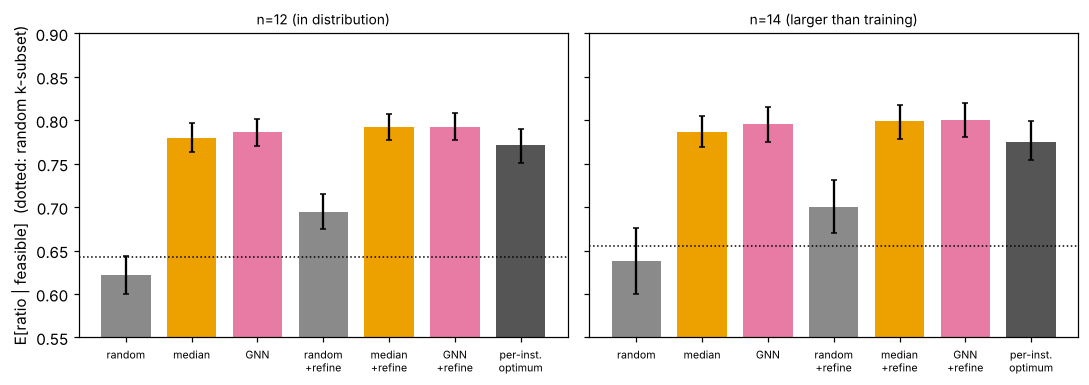

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for ax, set_name in zip(axes, tests):
    order = [('random', False), ('median', False), ('gnn', False), ('random', True), ('median', True), ('gnn', True), ('per-instance optimum', True)]
    labels = ['random', 'median', 'GNN', 'random\n+refine', 'median\n+refine', 'GNN\n+refine', 'per-inst.\noptimum']
    cols = [COLORS['random'], COLORS['median'], COLORS['gnn']] * 2 + ['#555555']
    vals = [boot_ci(e2_df[(e2_df.set == set_name) & (e2_df.method == m) & (e2_df.refined == r)].ratio_cond, seed=6) for m, r in order]
    m_, lo, hi = np.array(vals).T
    ax.bar(range(len(order)), m_, 0.75, yerr=[m_ - lo, hi - m_], capsize=2, color=cols)
    ax.axhline(e2_df[(e2_df.set == set_name) & (e2_df.method == 'uniform random subset')].ratio_cond.mean(), color='k', ls=':', lw=1)
    ax.set_xticks(range(len(order))); ax.set_xticklabels(labels, fontsize=7); ax.set_title(set_name, fontsize=9)
    ax.set_ylim(0.55, 0.9)
axes[0].set_ylabel('E[ratio | feasible]  (dotted: random k-subset)')
plt.tight_layout(); plt.show()

**Reading.**
- *Parameter concentration is the main effect.* A single parameter vector, the median of the training
  optima, is as good as or better than optimising each test instance from random starts, at both sizes. The
  per-instance optimiser with 4 restarts lands in worse local optima than the transferred parameters, so
  for this ansatz the expensive step is not needed at all at $p=2$.
- *The GNN* (trained only on the energy, no labels) learns instance-specific corrections that give a small but
  consistent improvement over the median without optimisation (+0.006 at $n=12$, +0.008 at $n=14$), and it
  generalises to a size it never saw. After 30 COBYLA iterations both converge to the same value, so the
  model's practical value is in the zero-optimisation regime.
- *An earlier version of the network failed* (zero-shot ratio ≈ 0.66, no better than random). Its output
  layer forced $\tilde\gamma \ge 0$ and $\beta \in (0, \pi/2)$, while the optimal scaled angles here have $\tilde\gamma < 0$. Removing the
  constraint fixed it; the model was selected on the training loss only.
- *Limits.* $p = 2$ only, one instance distribution, $n \le 14$. A fair test of learning needs regimes where
  concentration fails (more heterogeneous instances, larger $p$), which is where an instance-aware model
  should matter.

## E3. Beyond QUBO: the exact coverage Hamiltonian

The true objective is a polynomial of high degree:
$f(x) = \sum_{z} \big[1 - \prod_{i \in N(z)} (1 - x_i)\big]$, with $N(z)$ the stations covering zone $z$.
Expanded in Pauli-$Z$ operators it contains terms of weight up to $\max_z |N(z)|$. The quadratic
proxy $g_1$ keeps only weights $\le 2$. In simulation both are just diagonals, so the two cost
Hamiltonians can be compared directly in the same XY-mixer circuit; on hardware, a weight-$w$
$Z$-string costs $2(w-1)$ CNOTs plus routing.

**Instances.** Family R ($n = 12$, radius 2.2, 20 instances); a dense family D ($n = 12$, radius 3.5,
$k = 6$, 20 instances), where zones are covered several times; and family F (12 dense instances
rejection-sampled so that the proxy's maximiser is **not** a true optimum).

In [11]:
E3_SETS = {'R (sparse)': (2.2, 4, 20, False), 'D (dense)': (3.5, 6, 20, False), 'F (proxy fails)': (3.5, 6, 12, True)}
e3_inst = {}
for name, (radius, k_, count, need_fail) in E3_SETS.items():
    out, s = [], 0
    while len(out) < count:
        inst = Instance(make_instance(12, seed=1_400_000 + int(radius * 1000) + s, radius=radius), k_)
        if not need_fail or proxy_argmax_ratio(inst)[0] < 1:
            out.append(inst)
        s += 1
    e3_inst[name] = out
    print(f'{name}: {count} instances from {s} draws; mean fraction of zones covered >=3 times by an optimum: '
          f"{np.mean([((i.cov[bits_to_sel(np.where(i.feas & (i.tc == i.opt))[0][0], 12)].sum(0) >= 3).sum() / 25) for i in out]):.3f}")

e3_rows = []
t0 = time.time()
for name, insts in e3_inst.items():
    for j, inst in enumerate(insts):
        for cost in ['proxy', 'exact']:
            for p in [1, 2, 3]:
                _, pr, *_ = optimise_qaoa(inst, 'native_dicke', p, N_RESTARTS, SEED + 31 * j + p, GAMMA_SCALE_XY, MAXITER, built=xy_built(inst, p, cost))
                e3_rows.append({'set': name, 'instance': j, 'cost': cost, 'p': p, **output_metrics(inst, pr)})
    print(f'{name} done [{time.time() - t0:.0f}s]')
e3_df = pd.DataFrame(e3_rows)
e3_df.to_csv(f'{RESULTS_DIR}/e3_beyond_qubo.csv', index=False)

rows, tests3 = [], []
for name in E3_SETS:
    for p in [1, 2, 3]:
        r = {'set': name, 'p': p}
        for cost in ['proxy', 'exact']:
            s_ = e3_df[(e3_df.set == name) & (e3_df.cost == cost) & (e3_df.p == p)]
            r[f'E[ratio|feas] {cost}'] = fmt_ci(boot_ci(s_.ratio_cond, seed=7))
            r[f'P(opt) {cost}'] = fmt_ci(boot_ci(s_.p_opt, seed=7))
        rows.append(r)
        a = e3_df[(e3_df.set == name) & (e3_df.cost == 'exact') & (e3_df.p == p)].sort_values('instance')
        b = e3_df[(e3_df.set == name) & (e3_df.cost == 'proxy') & (e3_df.p == p)].sort_values('instance')
        for met in ['ratio_cond', 'p_opt']:
            diff, pv = paired_test(a[met].values, b[met].values)
            tests3.append({'set': name, 'p': p, 'metric': met, 'exact - proxy [95% CI]': fmt_ci(boot_ci(diff, seed=8)),
                           'wins': int((diff > 0).sum()), 'losses': int((diff < 0).sum()), 'wilcoxon_p': pv})
e3_tab = pd.DataFrame(rows).set_index(['set', 'p'])
e3_tests = pd.DataFrame(tests3)
display(e3_tab)
display(e3_tests.round(4))

R (sparse): 20 instances from 20 draws; mean fraction of zones covered >=3 times by an optimum: 0.000
D (dense): 20 instances from 20 draws; mean fraction of zones covered >=3 times by an optimum: 0.168


F (proxy fails): 12 instances from 62 draws; mean fraction of zones covered >=3 times by an optimum: 0.253


R (sparse) done [206s]


D (dense) done [406s]


F (proxy fails) done [527s]


E[ratio|feas] proxy          P(opt) proxy  \
set             p                                               
R (sparse)      1  0.747 [0.727, 0.767]  0.035 [0.022, 0.050]   
                2  0.774 [0.752, 0.796]  0.056 [0.031, 0.086]   
                3  0.793 [0.774, 0.813]  0.067 [0.041, 0.096]   
D (dense)       1  0.932 [0.922, 0.942]  0.306 [0.239, 0.376]   
                2  0.936 [0.925, 0.947]  0.332 [0.261, 0.403]   
                3  0.940 [0.931, 0.950]  0.342 [0.271, 0.415]   
F (proxy fails) 1  0.919 [0.910, 0.929]  0.201 [0.148, 0.254]   
                2  0.924 [0.916, 0.933]  0.196 [0.148, 0.245]   
                3  0.926 [0.918, 0.935]  0.222 [0.155, 0.300]   

                    E[ratio|feas] exact          P(opt) exact  
set             p                                              
R (sparse)      1  0.757 [0.736, 0.778]  0.038 [0.024, 0.055]  
                2  0.786 [0.765, 0.806]  0.060 [0.036, 0.091]  
                3  0.795 [0.773, 0.816]  0.065 [0.035, 0.102]  
D (dense)       1  0.937 [0.928, 0.947]  0.323 [0.256, 0.394]  
                2  0.941 [0.928, 0.952]  0.345 [0.274, 0.421]  
                3  0.942 [0.932, 0.952]  0.352 [0.274, 0.435]  
F (proxy fails) 1  0.928 [0.914, 0.940]  0.246 [0.183, 0.307]  
                2  0.938 [0.928, 0.948]  0.291 [0.229, 0.355]  
                3  0.933 [0.916, 0.946]  0.284 [0.217, 0.343]

,set,p,metric,exact - proxy [95% CI],wins,losses,wilcoxon_p
0,R (sparse),1,ratio_cond,"0.009 [0.006, 0.013]",18,1,0.0002
1,R (sparse),1,p_opt,"0.003 [0.002, 0.006]",16,3,0.0005
2,R (sparse),2,ratio_cond,"0.011 [-0.000, 0.024]",16,3,0.0141
3,R (sparse),2,p_opt,"0.004 [-0.011, 0.018]",14,5,0.0910
4,R (sparse),3,ratio_cond,"0.002 [-0.010, 0.014]",9,10,0.9359
5,R (sparse),3,p_opt,"-0.002 [-0.013, 0.011]",6,13,0.3547
6,D (dense),1,ratio_cond,"0.005 [0.002, 0.009]",14,6,0.0056
7,D (dense),1,p_opt,"0.017 [-0.011, 0.048]",13,7,0.2455
8,D (dense),2,ratio_cond,"0.005 [-0.006, 0.014]",12,8,0.2305
9,D (dense),2,p_opt,"0.013 [-0.034, 0.063]",12,8,0.5706


pauli_terms  max_weight  two_qubit_gates_p1
set             cost                                              
D (dense)       exact        565.3         7.7              3987.8
                proxy         60.0         2.0               303.7
F (proxy fails) exact        777.0         9.0              5477.3
                proxy         64.7         2.0               322.3
R (sparse)      exact         44.3         4.3               231.0
                proxy         26.0         2.0               133.3

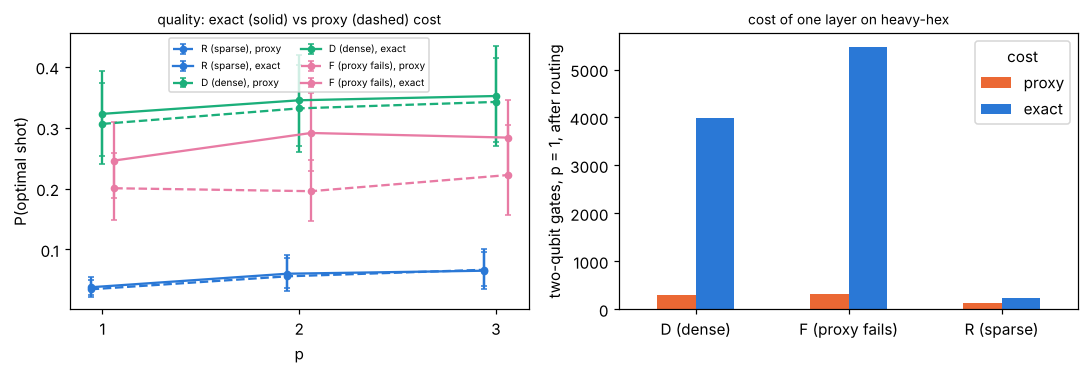

In [12]:
# Gate cost of one cost layer: Pauli structure and two-qubit gates after routing (FakeMarrakesh)
fake = FakeMarrakesh()
cost_rows = []
for name in E3_SETS:
    for inst in e3_inst[name][:3]:
        for cost in ['proxy', 'exact']:
            d = -inst.proxy if cost == 'proxy' else -inst.tc.astype(float)
            H, _ = diag_to_sparse_pauli(d)
            weights = [str(P_).count('Z') for P_ in H.paulis]
            qc = qiskit_native_circuit(inst, 1, H).assign_parameters([0.37, 0.11])
            qc.measure_all()
            n2 = [sum(1 for ins in generate_preset_pass_manager(backend=fake, optimization_level=1, seed_transpiler=ts).run(qc).data
                      if ins.operation.num_qubits == 2) for ts in range(3)]
            cost_rows.append({'set': name, 'cost': cost, 'pauli_terms': len(weights), 'max_weight': max(weights),
                              'two_qubit_gates_p1': float(np.mean(n2))})
e3_cost = pd.DataFrame(cost_rows)
e3_cost.to_csv(f'{RESULTS_DIR}/e3_gate_cost.csv', index=False)
e3_cost_tab = e3_cost.groupby(['set', 'cost'])[['pauli_terms', 'max_weight', 'two_qubit_gates_p1']].mean().round(1)
display(e3_cost_tab)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for k_, name in enumerate(E3_SETS):
    for cost, ls in [('proxy', '--'), ('exact', '-')]:
        st = [boot_ci(e3_df[(e3_df.set == name) & (e3_df.cost == cost) & (e3_df.p == p)].p_opt, seed=9) for p in [1, 2, 3]]
        m_, lo, hi = np.array(st).T
        axes[0].errorbar(np.array([1, 2, 3]) + 0.06 * (k_ - 1), m_, yerr=[m_ - lo, hi - m_], ls=ls, marker='o', ms=4, capsize=2,
                         color=['#2a78d6', '#1baf7a', '#e87ba4'][k_], label=f'{name}, {cost}')
axes[0].set_xticks([1, 2, 3]); axes[0].set_xlabel('p'); axes[0].set_ylabel('P(optimal shot)'); axes[0].legend(fontsize=6.5, ncol=2)
axes[0].set_title('quality: exact (solid) vs proxy (dashed) cost', fontsize=9)
ct = e3_cost.groupby(['set', 'cost']).two_qubit_gates_p1.mean().unstack()
ct[['proxy', 'exact']].plot.bar(ax=axes[1], color=[COLORS['proxy'], COLORS['exact']], rot=0)
axes[1].set_ylabel('two-qubit gates, p = 1, after routing'); axes[1].set_xlabel(''); axes[1].set_title('cost of one layer on heavy-hex', fontsize=9)
plt.tight_layout(); plt.show()

**Reading.** Leaving the QUBO pays off where, and roughly only where, the quadratic proxy is wrong.
On family F the exact Hamiltonian raises the probability of an optimal shot significantly at $p = 1$ and $2$.
On the sparse family the proxy is already exact, and the small early gain disappears by $p = 3$; on the dense
family differences are within noise. The price is steep: the exact cost contains Pauli-$Z$ strings up to weight
7–9 on dense instances, and one cost layer needs 13–17× the two-qubit gates of the proxy after routing. The
instances where the exact objective helps are exactly those where it is most expensive. The natural middle
ground, not tested here, is a truncation at weight 3 (inclusion–exclusion to third order), which removes the
proxy's main error ($m = 3$ zones) at a fraction of the cost.

## E4. Quantum samples as pretraining for a classical generative solver

**Question.** E1 used QAOA samples as starting points for a local search. A more "AI" use of the same
samples: pretrain a classical **generative model** on a few QAOA shots, then keep improving it classically,
with no further quantum calls. Does pretraining on quantum samples help the classical solver, compared
with pretraining on equally many random subsets, or with no pretraining?

**Model.** An autoregressive recurrent network (GRU, hidden size 32) that outputs the bits $x_1 \dots x_n$
one at a time, $p_\phi(x) = \prod_i p_\phi(x_i \mid x_{<i})$, with the budget enforced exactly by masking (once
$k$ stations are chosen the rest are forced to 0; if the remaining positions must all be 1 they are forced
to 1). Every sample is feasible, and $p_\phi$ can be evaluated exactly on all $\binom{n}{k}$ feasible strings.
Recurrent autoregressive models of this kind are used for neural quantum states and for variational neural
annealing (Hibat-Allah et al. 2021).

**Protocol** (per instance, `N_GEN_SEEDS` model seeds):
1. *Pretraining*, by maximum likelihood on `N_PRETRAIN_SHOTS` samples from one of three sources: the
   XY-QAOA circuit of E1 ($p=3$), uniformly random $k$-subsets (control: same data, no quantum information),
   or nothing.
2. *Classical fine-tuning*: variational annealing on the **true** coverage, $\min_\phi \mathbb{E}_{p_\phi}[-f(x)/Z] - T_t\,H(p_\phi)$ with
   $Z$ the number of zones (the optimum is not used) and temperature $T_t$ annealed linearly from `T0` to 0
   over `N_FT_STEPS` REINFORCE steps of `BATCH` samples.
3. *Evaluation* of the exact model distribution after each phase: expected ratio and probability of
   sampling an optimum.

In [13]:
N_PRETRAIN_SHOTS, PRETRAIN_STEPS, N_FT_STEPS, BATCH, T0, LR_GEN, N_GEN_SEEDS = 50, 300, 300, 64, 0.1, 1e-2, 2
CHECKPOINTS = [0, 10, 25, 50, 100, 200, 300]


class ConstrainedARGen(torch.nn.Module):
    def __init__(self, n, k, h=32):
        super().__init__()
        self.n, self.k = n, k
        self.cell = torch.nn.GRUCell(2, h)
        self.out = torch.nn.Linear(h, 1)
        self.h0 = torch.nn.Parameter(torch.zeros(h))

    def _mask(self, logit, ones, i):
        must0, must1 = ones >= self.k, (self.k - ones) >= (self.n - i)
        logit = torch.where(must0, torch.full_like(logit, -1e9), logit)
        return torch.where(must1, torch.full_like(logit, 1e9), logit)

    def log_prob(self, X):
        B = X.shape[0]
        h, prev, ones, lp = self.h0.expand(B, -1), torch.zeros(B, 2), torch.zeros(B), torch.zeros(B)
        for i in range(self.n):
            h = self.cell(prev, h)
            logit = self._mask(self.out(h).squeeze(-1), ones, i)
            xi = X[:, i]
            lp = lp + xi * torch.nn.functional.logsigmoid(logit) + (1 - xi) * torch.nn.functional.logsigmoid(-logit)
            prev = torch.stack([xi, 1 - xi], dim=1)
            ones = ones + xi
        return lp

    @torch.no_grad()
    def sample(self, B, gen):
        h, prev, ones = self.h0.expand(B, -1), torch.zeros(B, 2), torch.zeros(B)
        X = torch.zeros(B, self.n)
        for i in range(self.n):
            h = self.cell(prev, h)
            pr = torch.sigmoid(self._mask(self.out(h).squeeze(-1), ones, i))
            xi = (torch.rand(B, generator=gen) < pr).double()
            X[:, i] = xi
            prev = torch.stack([xi, 1 - xi], dim=1)
            ones = ones + xi
        return X


def to_bits(zs, n):
    return torch.tensor([[(int(z) >> i) & 1 for i in range(n)] for z in zs], dtype=torch.float64)


def bits_to_z(X):
    return (X.long() * (2 ** torch.arange(X.shape[1]))).sum(1).numpy()


def exact_eval(model, inst, feas_bits, ratio_f):
    with torch.no_grad():
        p = torch.exp(model.log_prob(feas_bits)).numpy()
    p = p / p.sum()
    return float((p * ratio_f).sum()), float(p[ratio_f == 1].sum())


e4_rows = []
t0 = time.time()
for set_name in E1_SETS:
    for j, inst in enumerate(e1_inst[set_name]):
        zf = np.where(inst.feas)[0]
        feas_bits = to_bits(zf, inst.n)
        ratio_f = inst.tc[zf] / inst.opt
        reward_of = lambda X: torch.tensor(inst.tc[bits_to_z(X)] / 25.0)
        pr_xy = e1_probs[(set_name, j)]
        for gs in range(N_GEN_SEEDS):
            rng = np.random.default_rng(SEED + 7919 * j + 101 * gs)
            data = {'qaoa': rng.choice(pr_xy.size, size=N_PRETRAIN_SHOTS, p=pr_xy / pr_xy.sum()),
                    'random': rng.choice(zf, size=N_PRETRAIN_SHOTS), 'none': None}
            for src, zs in data.items():
                torch.manual_seed(SEED + 13 * j + gs)
                gen = torch.Generator().manual_seed(SEED + 17 * j + gs)
                model = ConstrainedARGen(inst.n, inst.k)
                opt = torch.optim.Adam(model.parameters(), lr=LR_GEN)
                if zs is not None:
                    Xd = to_bits(zs, inst.n)
                    for _ in range(PRETRAIN_STEPS):
                        opt.zero_grad(); (-model.log_prob(Xd).mean()).backward(); opt.step()
                opt = torch.optim.Adam(model.parameters(), lr=LR_GEN)
                for step in range(N_FT_STEPS + 1):
                    if step in CHECKPOINTS:
                        er, po = exact_eval(model, inst, feas_bits, ratio_f)
                        e4_rows.append({'set': set_name, 'instance': j, 'seed': gs, 'pretrain': src, 'step': step,
                                        'ratio_cond': er, 'p_opt': po})
                    if step == N_FT_STEPS:
                        break
                    T = T0 * (1 - step / N_FT_STEPS)
                    X = model.sample(BATCH, gen)
                    lp = model.log_prob(X)
                    cost = -reward_of(X) + T * lp.detach()          # free energy per sample (entropy term)
                    loss = ((cost - cost.mean()) * lp).mean()       # REINFORCE with mean baseline
                    opt.zero_grad(); loss.backward(); opt.step()
    print(f'{set_name} done [{time.time() - t0:.0f}s]')
e4_df = pd.DataFrame(e4_rows)
e4_df.to_csv(f'{RESULTS_DIR}/e4_generative_pretraining.csv', index=False)

R, n=12 done [416s]


R, n=14 done [709s]


H, n=12 done [963s]


E[ratio] qaoa           P(opt) qaoa  \
set     fine-tuning steps                                               
R, n=12 0                  0.762 [0.738, 0.786]  0.055 [0.031, 0.087]   
        25                 0.751 [0.723, 0.779]  0.066 [0.045, 0.088]   
        300                0.979 [0.964, 0.990]  0.816 [0.695, 0.904]   
R, n=14 0                  0.769 [0.735, 0.802]  0.039 [0.013, 0.082]   
        25                 0.743 [0.701, 0.785]  0.038 [0.004, 0.085]   
        300                0.960 [0.928, 0.986]  0.697 [0.521, 0.851]   
H, n=12 0                  0.819 [0.802, 0.834]  0.024 [0.007, 0.044]   
        25                 0.820 [0.807, 0.831]  0.031 [0.016, 0.048]   
        300                0.986 [0.979, 0.992]  0.785 [0.672, 0.890]   

                                E[ratio] random         P(opt) random  \
set     fine-tuning steps                                               
R, n=12 0                  0.605 [0.579, 0.632]  0.006 [0.004, 0.010]   
        25                 0.691 [0.667, 0.715]  0.032 [0.019, 0.048]   
        300                0.961 [0.935, 0.982]  0.753 [0.626, 0.862]   
R, n=14 0                  0.646 [0.606, 0.684]  0.009 [0.002, 0.020]   
        25                 0.698 [0.662, 0.733]  0.017 [0.003, 0.041]   
        300                0.945 [0.921, 0.966]  0.488 [0.301, 0.671]   
H, n=12 0                  0.737 [0.715, 0.759]  0.009 [0.003, 0.016]   
        25                 0.784 [0.771, 0.797]  0.029 [0.014, 0.047]   
        300                0.978 [0.971, 0.985]  0.675 [0.550, 0.794]   

                                  E[ratio] none           P(opt) none  
set     fine-tuning steps                                              
R, n=12 0                  0.592 [0.555, 0.626]  0.010 [0.004, 0.019]  
        25                 0.651 [0.630, 0.672]  0.019 [0.011, 0.029]  
        300                0.973 [0.952, 0.989]  0.805 [0.683, 0.912]  
R, n=14 0                  0.660 [0.612, 0.703]  0.016 [0.001, 0.041]  
        25                 0.677 [0.642, 0.712]  0.012 [0.002, 0.027]  
        300                0.957 [0.905, 0.992]  0.700 [0.496, 0.894]  
H, n=12 0                  0.711 [0.682, 0.739]  0.005 [0.002, 0.010]  
        25                 0.753 [0.730, 0.774]  0.013 [0.006, 0.023]  
        300                0.982 [0.970, 0.991]  0.652 [0.401, 0.850]

,set,step,comparison,metric,mean diff [95% CI],wins,losses,wilcoxon_p
1,"R, n=12",0,qaoa - random,p_opt,"0.049 [0.027, 0.076]",19,1,0.0000
3,"R, n=12",0,qaoa - none,p_opt,"0.045 [0.025, 0.069]",18,2,0.0000
5,"R, n=12",25,qaoa - random,p_opt,"0.034 [0.018, 0.051]",16,4,0.0009
7,"R, n=12",25,qaoa - none,p_opt,"0.047 [0.028, 0.068]",17,3,0.0002
9,"R, n=12",300,qaoa - random,p_opt,"0.063 [-0.038, 0.167]",10,10,0.5706
11,"R, n=12",300,qaoa - none,p_opt,"0.011 [-0.130, 0.169]",9,11,0.5217
13,"R, n=14",0,qaoa - random,p_opt,"0.030 [0.010, 0.061]",12,0,0.0005
15,"R, n=14",0,qaoa - none,p_opt,"0.023 [0.007, 0.043]",8,4,0.0425
17,"R, n=14",25,qaoa - random,p_opt,"0.021 [0.002, 0.050]",10,2,0.0425
19,"R, n=14",25,qaoa - none,p_opt,"0.026 [0.002, 0.059]",10,2,0.0269


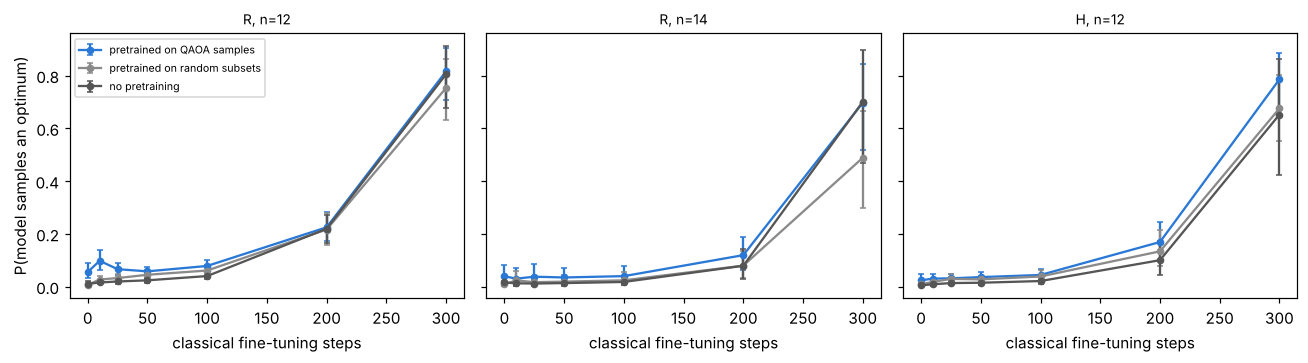

In [14]:
e4_inst = e4_df.groupby(['set', 'instance', 'pretrain', 'step'])[['ratio_cond', 'p_opt']].mean().reset_index()
PRE_LABEL = {'qaoa': 'pretrained on QAOA samples', 'random': 'pretrained on random subsets', 'none': 'no pretraining'}
PRE_COL = {'qaoa': COLORS['xy'], 'random': COLORS['random'], 'none': '#555555'}
rows = []
for set_name in E1_SETS:
    for step in [0, 25, N_FT_STEPS]:
        r = {'set': set_name, 'fine-tuning steps': step}
        for src in PRE_LABEL:
            s_ = e4_inst[(e4_inst.set == set_name) & (e4_inst.pretrain == src) & (e4_inst.step == step)]
            r[f'E[ratio] {src}'] = fmt_ci(boot_ci(s_.ratio_cond, seed=14))
            r[f'P(opt) {src}'] = fmt_ci(boot_ci(s_.p_opt, seed=14))
        rows.append(r)
e4_tab = pd.DataFrame(rows).set_index(['set', 'fine-tuning steps'])
display(e4_tab)

e4_tests = []
for set_name in E1_SETS:
    for step in [0, 25, N_FT_STEPS]:
        a = e4_inst[(e4_inst.set == set_name) & (e4_inst.pretrain == 'qaoa') & (e4_inst.step == step)].sort_values('instance')
        for other in ['random', 'none']:
            b = e4_inst[(e4_inst.set == set_name) & (e4_inst.pretrain == other) & (e4_inst.step == step)].sort_values('instance')
            for met in ['ratio_cond', 'p_opt']:
                diff, pv = paired_test(a[met].values, b[met].values)
                e4_tests.append({'set': set_name, 'step': step, 'comparison': f'qaoa - {other}', 'metric': met,
                                 'mean diff [95% CI]': fmt_ci(boot_ci(diff, seed=15)), 'wins': int((diff > 0).sum()),
                                 'losses': int((diff < 0).sum()), 'wilcoxon_p': pv})
e4_tests = pd.DataFrame(e4_tests)
display(e4_tests[e4_tests.metric == 'p_opt'].round(4))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, set_name in zip(axes, E1_SETS):
    for src in PRE_LABEL:
        st = [boot_ci(e4_inst[(e4_inst.set == set_name) & (e4_inst.pretrain == src) & (e4_inst.step == c)].p_opt, seed=16) for c in CHECKPOINTS]
        m_, lo, hi = np.array(st).T
        ax.errorbar(CHECKPOINTS, m_, yerr=[m_ - lo, hi - m_], marker='o', ms=4, capsize=2, color=PRE_COL[src], label=PRE_LABEL[src])
    ax.set_title(set_name, fontsize=9); ax.set_xlabel('classical fine-tuning steps')
axes[0].set_ylabel('P(model samples an optimum)'); axes[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

**Reading.**
- *Quantum pretraining gives a head start.* Before any classical fine-tuning, the model pretrained on 50
  XY-QAOA shots puts more probability on optimal selections than one pretrained on 50 random subsets
  (+0.049 at $n=12$, 19 wins / 1 loss; +0.030 at $n=14$, 12/0) or an untrained model. The lead persists
  through the first 25 annealing steps on family R.
- *The head start does not survive full fine-tuning.* After 300 steps of variational annealing the three
  variants end at similar quality (differences not significant against no pretraining). The only lasting
  effect is negative for the control: pretraining on random subsets leaves the $n=14$ model worse than
  QAOA pretraining (+0.209 in $p_{\rm opt}$ for QAOA, 10/2), consistent with the model memorising 50 arbitrary strings.
- *On the hard family* the early advantage is smaller and mostly not significant.
- *So,* at this size quantum samples act as a warm start worth some tens of classical training steps, not as
  something the classical generative solver cannot reach alone. Whether the head start grows with $n$ —
  where classical annealing becomes slow and quantum samples are expensive to imitate — is the question
  worth pursuing; $n \le 14$ cannot answer it.

## Summary (computed)

In [15]:
def m(df, **kw):
    s_ = df
    for k_, v in kw.items():
        s_ = s_[s_[k_] == v]
    return s_


ext_summary = {
    'run_minutes': round((time.time() - RUN_STARTED) / 60, 1),
    'E1': {s: {src: boot_ci(m(e1_df, set=s, source=src).p_success, seed=11) for src in SOURCES} for s in E1_SETS},
    'E1_tests': e1_tests.to_dict(orient='records'),
    'E2': {s: {f'{meth}|{ref}': boot_ci(m(e2_df, set=s, method=meth, refined=ref).ratio_cond, seed=12)
               for meth, ref in [('random', False), ('median', False), ('gnn', False), ('random', True), ('median', True), ('gnn', True),
                                 ('per-instance optimum', True), ('uniform random subset', False)]} for s in tests},
    'E2_tests': e2_tests.to_dict(orient='records'),
    'E2_train_loss': {'gnn': best_loss, 'median': med_train},
    'E3': {s: {f'{c}|p={p}|{met}': boot_ci(m(e3_df, set=s, cost=c, p=p)[met], seed=13)
               for c in ['proxy', 'exact'] for p in [1, 2, 3] for met in ['ratio_cond', 'p_opt']} for s in E3_SETS},
    'E3_tests': e3_tests.to_dict(orient='records'),
    'E4': {s: {f'{src}|step={st}|{met}': boot_ci(m(e4_inst, set=s, pretrain=src, step=st)[met], seed=17)
               for src in ['qaoa', 'random', 'none'] for st in [0, 25, N_FT_STEPS] for met in ['ratio_cond', 'p_opt']} for s in E1_SETS},
    'E4_tests': e4_tests.to_dict(orient='records'),
    'E3_cost': e3_cost.groupby(['set', 'cost'])[['pauli_terms', 'max_weight', 'two_qubit_gates_p1']].mean().reset_index().to_dict(orient='records'),
}
with open(f'{RESULTS_DIR}/summary_ext.json', 'w') as fh:
    json.dump(ext_summary, fh, indent=1, default=float)
print(f"total run time: {ext_summary['run_minutes']} min")

total run time: 43.3 min
